In [1]:
import os
import re
import pandas as pd

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

figures_dir = os.path.join(repo_dir, "03_error/figures")
os.makedirs(figures_dir, exist_ok=True)

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /Users/haya1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/haya1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Data Preprocessing

In [2]:
SEED = 123
STOPWORDS = nltk.corpus.stopwords.words('english')
LEMMATIZER = nltk.stem.WordNetLemmatizer()
VECTORIZER = CountVectorizer()

In [3]:
def clean_text(x):    
    # lowecase and remove punctuation
    x = re.sub(r'[^a-zA-Z]', ' ', x.lower())

    # remove stopwords 
    words = [word for word in x.split() if word not in set(STOPWORDS)]

    # stemming (maybe omit and see if results change?)
    words = [LEMMATIZER.lemmatize(word) for word in words]
    
    # join back into string and return (sklearn vectorizer wants string as input)
    return ' '.join(words)

def bag_of_words(x):
    # Create BOW representation    
    x_clean = x.apply(clean_text) #(x)
    return VECTORIZER.fit_transform(x_clean)

In [4]:
bills_prompts_responses = pd.read_csv(os.path.join(repo_dir, f"02_llm/bills_prompts_responses_10000.csv"))
X = bag_of_words(bills_prompts_responses["Description"])
y = bills_prompts_responses["Major"] !=  bills_prompts_responses["MajorLLM"]

## Logistic Regression

In [5]:
models = bills_prompts_responses["Model"].unique()
prompt_mods = bills_prompts_responses["PromptingStrategyID"].unique()

regressions = []
for model in models:
    for prompt_mod in prompt_mods:
        for regularizer in ['Lasso', 'Ridge']:
            condition = (bills_prompts_responses["Model"]==model) & (bills_prompts_responses["PromptingStrategyID"]==prompt_mod)
            X_subset = X[condition]
            y_subset = y[condition]

            X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.5, random_state=SEED)

            # Logistic Regression with penalty
            penalty = 'l1' if (regularizer=='Lasso') else 'l2'
            logistic_model = LogisticRegression(penalty=penalty, solver='liblinear', max_iter=1000)
            logistic_model.fit(X_train, y_train)

            # Evaluate 
            y_pred  = logistic_model.predict(X_test) # 0 or 1
            y_probs = logistic_model.predict_proba(X_test)[:,1] # prob in one hot form, get column corresponding to 1
            fpr, tpr, _ = roc_curve(y_test, y_probs)

            regressions.append({
                "Model": model,
                "PromptModificationID": prompt_mod,
                "Regularizer": regularizer,
                "fpr": fpr,
                "tpr": tpr,
                "auc": auc(fpr, tpr),
                "accuracy": accuracy_score(y_test, y_pred),
                "classification_report": classification_report(y_test, y_pred)
            })

regressions = pd.json_normalize(regressions)

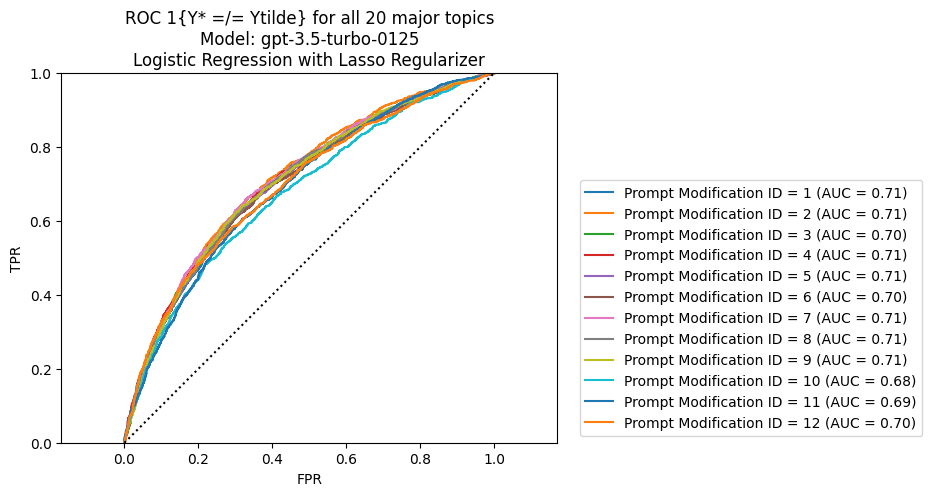

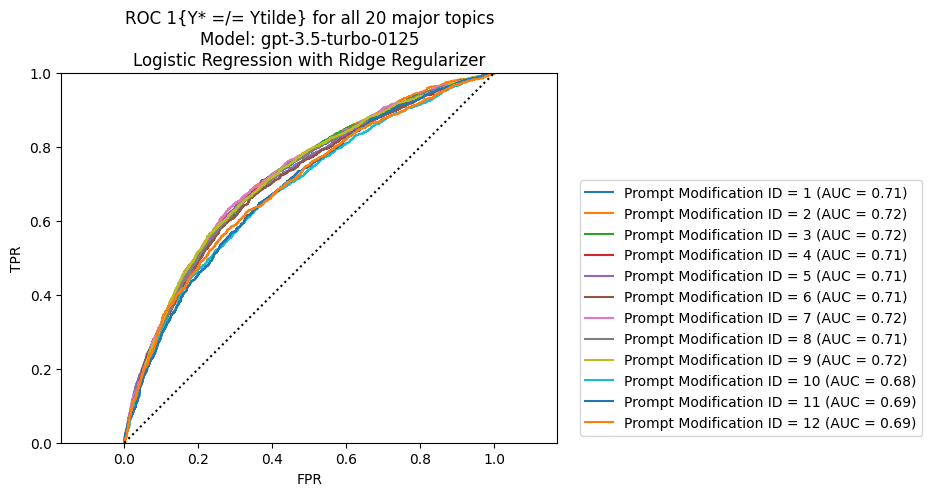

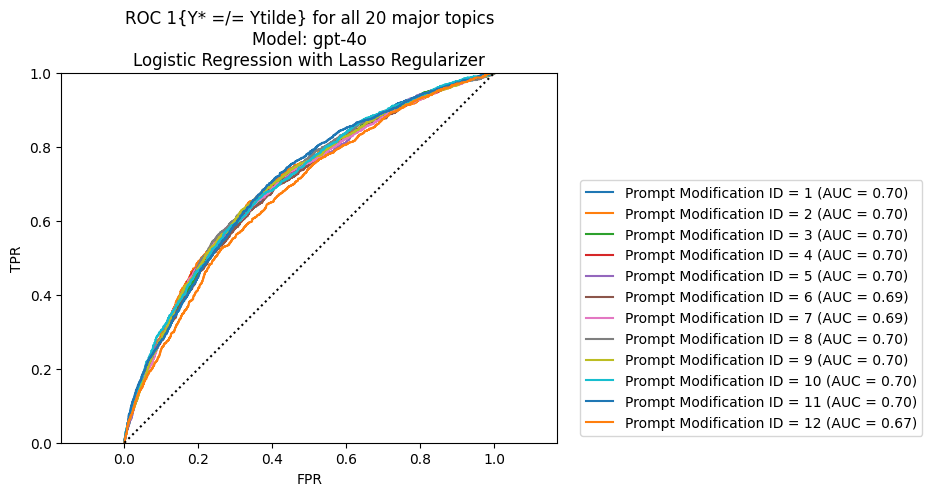

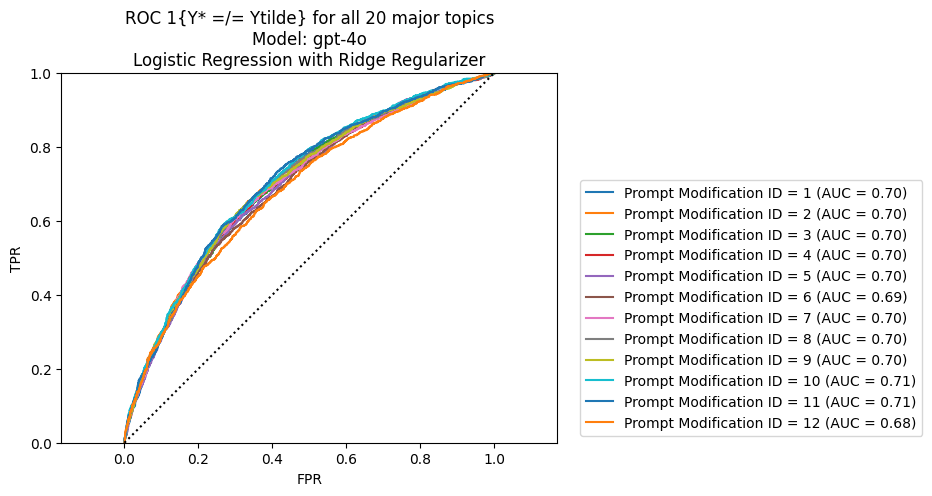

In [6]:
for model in regressions["Model"].unique():
    for regularizer in regressions["Regularizer"].unique():
        condition = (regressions["Regularizer"]==regularizer) &  (regressions["Model"]==model)
        regressions_subset = regressions[condition]

        # plot auc
        plt.figure()
        for _, regression in regressions_subset.iterrows():
            plt.plot(regression['fpr'], regression['tpr'], label=f"Prompt Modification ID = {regression['PromptModificationID']} (AUC = {regression['auc']:0.2f})")
        
        
        plt.plot([0, 1], [0, 1], linestyle='dotted', color='black')
        plt.title(f"ROC 1{{Y* =/= Ytilde}} for all 20 major topics\nModel: {regression['Model']}\nLogistic Regression with {regularizer} Regularizer")
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.legend(loc="lower right", bbox_to_anchor=(1.75, 0))
        plt.axis('equal')
        plt.ylim([0,1])
        plt.xlim([0,1])
        plt.savefig(os.path.join(figures_dir, f"{regression['Model']} {regression['Regularizer']}.png"), bbox_inches = "tight")